In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
import importlib

In [2]:
# Get the path of the notebook file
notebook_path = os.getcwd()

# Directory containing the notebook file
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [3]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import cubical_pers_and_filt_visual, globe_visualization, feature_tracking

importlib.reload(cubical_pers_and_filt_visual)
importlib.reload(globe_visualization)
importlib.reload(feature_tracking)

<module 'feature_tracking' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/feature_tracking.py'>

# Visulalization

In [4]:
# Load specific year and day
df = feature_tracking.load_all_representative_data_to_df(years=1948, days=1,notebook_dir=notebook_directory)
df

,year,day,data_type,feature_index,birth,death,persistence,representative,death_simplex_vertices
0,1948,1,sub,61,-54.341457,1685.783813,1740.125271,"[[[64, 74], [65, 74]], [[65, 74], [66, 74]], [...","[[105, 123], [106, 123], [105, 124], [106, 124]]"
1,1948,1,sub,60,207.378220,1677.995850,1470.617630,"[[[53, 7], [53, 8]], [[52, 8], [53, 8]], [[145...","[[83, 18], [84, 18], [83, 19], [84, 19]]"
2,1948,1,sub,59,139.274673,1246.956787,1107.682114,"[[[88, 109], [88, 110]], [[88, 110], [88, 111]...","[[64, 108], [65, 108], [64, 109], [65, 109]]"
3,1948,1,sub,58,-33.940052,504.925354,538.865406,"[[[111, 85], [112, 85]], [[112, 85], [113, 85]...","[[118, 72], [119, 72], [118, 73], [119, 73]]"
4,1948,1,sub,57,108.889824,624.874939,515.985115,"[[[46, 60], [46, 61]], [[46, 61], [46, 62]], [...","[[57, 56], [58, 56], [57, 57], [58, 57]]"
...,...,...,...,...,...,...,...,...,...
134,1948,1,sup,4,151.073303,151.747147,0.673843,"[[[74, 74], [75, 74]], [[75, 74], [76, 74]], [...","[[75, 72], [76, 72], [75, 73], [76, 73]]"
135,1948,1,sup,3,294.944153,295.232025,0.287872,"[[[134, 142], [135, 142]], [[135, 142], [136, ...","[[135, 140], [136, 140], [135, 141], [136, 141]]"
136,1948,1,sup,2,385.278778,385.528870,0.250092,"[[[102, 153], [102, 154]], [[102, 154], [103, ...","[[102, 152], [103, 152], [102, 153], [103, 153]]"
137,1948,1,sup,1,638.267822,638.491516,0.223694,"[[[26, 103], [27, 103]], [[27, 103], [28, 103]...","[[25, 101], [26, 101], [25, 102], [26, 102]]"


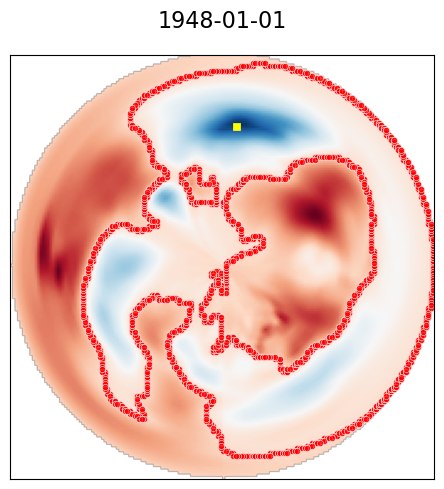

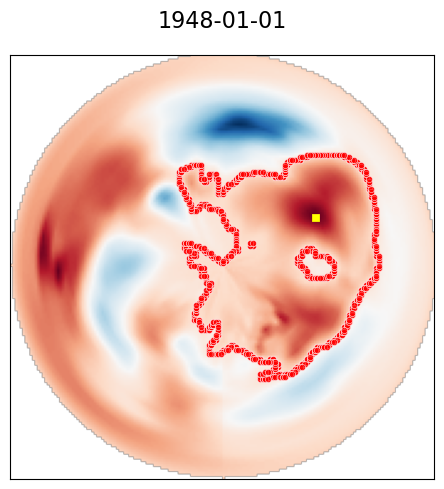

In [5]:
# Plot a specific feature
fig, ax = feature_tracking.plot_representative_on_heatmap(year=1948, day=1, data_type='sup', feature_index=76,notebook_dir=notebook_directory)
plt.show()

fig, ax = feature_tracking.plot_representative_on_heatmap(year=1948, day=1, data_type='sub', feature_index=61,notebook_dir=notebook_directory)
plt.show()

# Plot multiple features from the same day
# fig, ax = plot_multiple_features(df, year=1948, day=1, data_type='sub', max_features=3)
# plt.show()

# Tracking

## Sublevel

In [6]:
results_sub = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948,
    end_year=2023,
    data_type='sub',
    notebook_dir=notebook_directory,
    persistence_threshold=1000,
    alpha=0,
    beta=1,
    distance_threshold=1000,
    matrix_size=172
)

LOADING CACHED RESULTS
Loading cached results from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sub_1948-2023_pers1000_a0_b1_dist1000_size172.pkl
Cache created: 2026-04-03T09:21:10.295334
Total trajectories: 38221
Cached results loaded successfully!


In [7]:
# Plot the longest trajectory
longest_traj_id = results_sub['trajectory_lengths'].index(max(results_sub['trajectory_lengths']))
#feature_tracking.plot_trajectory(results_sub, longest_traj_id, notebook_dir=notebook_directory,figsize=(5,5))

In [8]:
feature_tracking.plot_trajectory_slider_with_persistence_fixed(results_sub, trajectory_id=31802, notebook_dir=notebook_directory)

Trajectory 31802: 2012-01-31 → 2012-02-05  (6 days)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-23.446254028320315), np.float64(54.61937536621094))


IntSlider(value=0, description='Traj 31802:', layout=Layout(width='500px'), max=5, style=SliderStyle(descripti…

Output()

Loading data for 2012-02-05 (Year: 2012, Day: 36)
Loading polar matrix from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/SLP_data_years/2012/slp_sub_2012_day_36.npy
Loaded polar matrix with shape: (172, 172)
Successfully plotted 2012-02-05


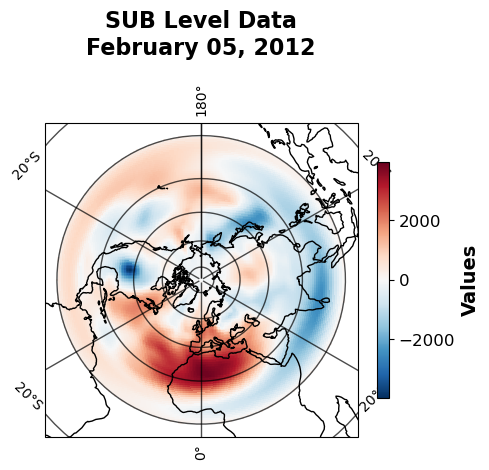

In [9]:
fig = globe_visualization.plot_date_polar_stereo("2012-02-05", data_type='sub',std_scaling=False, std_scale=2.0, notebook_dir=notebook_directory,figsize=(5, 5))

In [10]:
feature_tracking.plot_top_trajectories_slider(results_sub, notebook_dir=notebook_directory, top_n=10)

Interactive viewer for top 10 longest trajectories
  0: Trajectory 29243 - 17 points (2006-11-06 to 2006-11-22)
  1: Trajectory 219 - 16 points (1948-03-28 to 1948-04-12)
  2: Trajectory 26825 - 16 points (2001-12-10 to 2001-12-25)
  3: Trajectory 28445 - 16 points (2005-02-17 to 2005-03-04)
  4: Trajectory 7223 - 15 points (1962-04-18 to 1962-05-02)
  5: Trajectory 2320 - 14 points (1952-06-10 to 1952-06-23)
  6: Trajectory 2875 - 14 points (1953-06-17 to 1953-06-30)
  7: Trajectory 4646 - 14 points (1956-12-21 to 1957-01-04)
  8: Trajectory 20216 - 14 points (1989-01-31 to 1989-02-13)
  9: Trajectory 28974 - 13 points (2006-04-03 to 2006-04-15)


interactive(children=(IntSlider(value=0, description='Top Trajectory:', layout=Layout(width='400px'), max=9, s…

In [11]:
summary_df_sub = feature_tracking.get_trajectory_summary(results_sub)

Created summary DataFrame with 38221 trajectories


In [12]:
target_date = pd.Timestamp('2012-02-04')

active = summary_df_sub[
    (pd.to_datetime(summary_df_sub['start_date']) <= target_date) &
    (pd.to_datetime(summary_df_sub['end_date'])   >= target_date)
 ]

In [13]:
active

,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
350,31802,6,5,2012-01-31,2012-02-05,4416.018916,5114.766296,3422.331146,527.830952,27.211919,...,85.0,23.0,85.0,1659.281253,331.856251,475.621784,"[2012-01-31, 2012-02-01, 2012-02-02, 2012-02-0...","[(61.222900390625, 4710.9716796875), (-303.375...","[4649.748779296875, 5114.766296386719, 4374.64...","[(21.0, 85.0), (21.0, 82.0), (21.0, 77.0), (21..."


In [58]:
feature_tracking.plot_trajectory_slider_with_persistence_fixed(
    results_sub, 
    trajectory_id=31802, 
    fontsize=30,
    death_square_scale=3,
    notebook_dir=notebook_directory)

Trajectory 31802: 2012-01-31 → 2012-02-05  (6 days)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-23.446254028320315), np.float64(54.61937536621094))


IntSlider(value=0, description='Traj 31802:', layout=Layout(width='500px'), max=5, style=SliderStyle(descripti…

Output()

In [15]:
overlap_df, groups = feature_tracking.find_overlapping_trajectories(summary_df_sub,min_overlap_days=3,min_trajectory_length=3)
overlap_df.head(20)

Trajectories after length filter (>= 3): 3941 / 38221
Found 613 overlapping pairs among 1108 trajectories.


,traj_id_1,start_1,end_1,traj_id_2,start_2,end_2,overlap_start,overlap_end,overlap_days
0,26825,2001-12-10,2001-12-25,26814,2001-12-13,2001-12-19,2001-12-13,2001-12-19,7
1,24270,1996-12-26,1997-01-07,24265,1996-12-26,1997-01-01,1996-12-26,1997-01-01,7
2,13340,1974-12-06,1974-12-13,13341,1974-12-08,1974-12-13,1974-12-08,1974-12-13,6
3,30550,2009-04-21,2009-04-28,30546,2009-04-21,2009-04-26,2009-04-21,2009-04-26,6
4,28409,2005-01-28,2005-02-02,28408,2005-01-28,2005-02-02,2005-01-28,2005-02-02,6
5,34988,2018-01-19,2018-01-25,34987,2018-01-20,2018-01-25,2018-01-20,2018-01-25,6
6,29243,2006-11-06,2006-11-22,29240,2006-11-16,2006-11-20,2006-11-16,2006-11-20,5
7,15839,1980-02-02,1980-02-09,15836,1980-02-01,1980-02-06,1980-02-02,1980-02-06,5
8,31246,2010-12-03,2010-12-11,31245,2010-12-07,2010-12-11,2010-12-07,2010-12-11,5
9,37538,2022-09-24,2022-10-01,37532,2022-09-22,2022-09-28,2022-09-24,2022-09-28,5


In [16]:
feature_tracking.plot_two_trajectories_globe_slider(
    results_sub,
    trajectory_id_1=29243,
    trajectory_id_2=29240,
    notebook_dir=notebook_directory,
    fontsize=30,
    death_square_scale=3
)

Trajectory 29243: 2006-11-06 → 2006-11-22  (17 days)
Trajectory 29240: 2006-11-16 → 2006-11-20  (5 days)
Combined timeline: 2006-11-06 → 2006-11-22  (17 dates)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-29.89854760742188), np.float64(43.804072509765625))


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=16, style=Slid…

In [ ]:
feature_tracking.plot_two_trajectories_globe_slider(
    results_sub,
    trajectory_id_1=28409,
    trajectory_id_2=28408,
    notebook_dir=notebook_directory,
    fontsize=30,
    death_square_scale=3
)

Trajectory 28409: 2005-01-28 → 2005-02-02  (6 days)
Trajectory 28408: 2005-01-28 → 2005-02-02  (6 days)
Combined timeline: 2005-01-28 → 2005-02-02  (6 dates)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-24.340260009765625), np.float64(45.215516357421876))


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=5, style=Slide…

In [55]:
feature_tracking.plot_two_trajectories_globe_slider(
    results_sub,
    trajectory_id_1=26825,
    trajectory_id_2=26814,
    notebook_dir=notebook_directory,
    fontsize=30,
    death_square_scale=3,
    star_size=300
)

Trajectory 26825: 2001-12-10 → 2001-12-25  (16 days)
Trajectory 26814: 2001-12-13 → 2001-12-19  (7 days)
Combined timeline: 2001-12-10 → 2001-12-25  (16 dates)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-26.111365844726564), np.float64(49.24529284667969))


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=15, style=Slid…

In [19]:
feature_tracking.get_overall_summary_stats(results_sub,summary_df_sub)

=== TRAJECTORY ANALYSIS SUMMARY ===
Data type: sub
Start year: 1948
End year: 2023
Persistence threshold: 1000
Alpha (topological weight): 0
Beta (spatial weight): 1
Distance threshold: 1000
Matrix size: 172

=== TRAJECTORY LENGTH STATISTICS ===
Total trajectories: 38221
Mean length: 1.47 days
Median length: 1.00 days
Max length: 17 days
Min length: 1 days
Std length: 1.01 days

=== TRAJECTORY LIFESPAN STATISTICS ===
Mean lifespan: 0.47 days
Median lifespan: 0.00 days
Max lifespan: 16 days

=== PERSISTENCE STATISTICS ===
Mean persistence: 1659.0914
Max persistence (across all): 7280.9768
Min persistence (across all): 1000.0208
Std of mean persistence: 719.5630

=== BIRTH-DEATH STATISTICS ===
Mean birth value: 158.4457
Mean death value: 1817.5371

=== SPATIAL MOVEMENT STATISTICS ===
Mean total movement: 225.58 km
Max total movement: 6589.88 km
Mean avg movement per day: 138.92 km/day
Max single-day movement: 999.85 km

=== TRAJECTORY DURATION DISTRIBUTION ===
1 day: 27639 trajectories (

{'trajectory_count': 38221,
 'mean_length': np.float64(1.4679888019675047),
 'mean_lifespan': np.float64(0.4685905653959865),
 'mean_persistence': np.float64(1659.091383058559),
 'duration_distribution': trajectory_length
 1 day         27639
 2-4 days       9805
 5-9 days        731
 10-19 days       46
 20-49 days        0
 50-99 days        0
 100+ days         0
 Name: count, dtype: int64,
 'top_trajectories_by_length':                  trajectory_id  trajectory_length  trajectory_lifespan  \
 trajectory_rank                                                          
 1                        29243                 17                   16   
 2                          219                 16                   15   
 3                        26825                 16                   15   
 4                        28445                 16                   15   
 5                         7223                 15                   14   
 6                         4646                 

In [20]:
recommendations = feature_tracking.get_trajectory_recommendations(results_sub, summary_df_sub, notebook_directory)

=== TRAJECTORY RECOMMENDATIONS ===
LONGEST:
  Trajectory ID: 29243 (Rank 1)
  Reason: Longest duration trajectory
  Stats: 17 days, 16 day lifespan
  Plot command: plot_trajectory_slider(results, 29243, notebook_dir)

MOST_PERSISTENT:
  Trajectory ID: 22710 (Rank 7936)
  Reason: Highest average persistence
  Stats: Persistence: 7134.9429, 2 days
  Plot command: plot_trajectory_slider(results, 22710, notebook_dir)

MOST_MOBILE:
  Trajectory ID: 29243 (Rank 1)
  Reason: Greatest spatial movement
  Stats: Movement: 6589.88 km, 17 days
  Plot command: plot_trajectory_slider(results, 29243, notebook_dir)



## Superlevel

In [21]:
results_sup = feature_tracking.analyze_persistence_trajectories_cached(
    start_year=1948,
    end_year=2023,
    data_type='sup',
    notebook_dir=notebook_directory,
    persistence_threshold=1000,
    alpha=0,
    beta=1,
    distance_threshold=1000,
    matrix_size=172
)

LOADING CACHED RESULTS
Loading cached results from: /Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/data/processed_data/feature_tracking/trajectory_results_sup_1948-2023_pers1000_a0_b1_dist1000_size172.pkl
Cache created: 2026-04-03T09:29:49.631280
Total trajectories: 94169
Cached results loaded successfully!


In [22]:
# Plot the longest trajectory
longest_traj_id = results_sup['trajectory_lengths'].index(max(results_sup['trajectory_lengths']))
#feature_tracking.plot_trajectory(results, longest_traj_id, notebook_dir=notebook_directory,figsize=(5,5))

In [23]:
feature_tracking.plot_trajectory_slider_with_persistence_fixed(results_sup, trajectory_id=longest_traj_id, notebook_dir=notebook_directory)

Trajectory 19620: 1964-02-17 → 1964-02-27  (11 days)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-64.60132006835937), np.float64(24.88530200195313))


IntSlider(value=0, description='Traj 19620:', layout=Layout(width='500px'), max=10, style=SliderStyle(descript…

Output()

In [24]:
feature_tracking.plot_top_trajectories_slider(results_sup, notebook_dir=notebook_directory, top_n=10)

Interactive viewer for top 10 longest trajectories
  0: Trajectory 19620 - 11 points (1964-02-17 to 1964-02-27)
  1: Trajectory 19893 - 11 points (1964-05-01 to 1964-05-11)
  2: Trajectory 19887 - 9 points (1964-05-01 to 1964-05-09)
  3: Trajectory 30089 - 9 points (1972-07-15 to 1972-07-23)
  4: Trajectory 38299 - 9 points (1979-01-29 to 1979-02-06)
  5: Trajectory 54843 - 9 points (1992-07-11 to 1992-07-19)
  6: Trajectory 34487 - 8 points (1975-12-23 to 1975-12-30)
  7: Trajectory 37140 - 8 points (1978-02-12 to 1978-02-19)
  8: Trajectory 38468 - 8 points (1979-03-15 to 1979-03-22)
  9: Trajectory 56049 - 8 points (1993-07-08 to 1993-07-15)


interactive(children=(IntSlider(value=0, description='Top Trajectory:', layout=Layout(width='400px'), max=9, s…

In [25]:
summary_df_sup = feature_tracking.get_trajectory_summary(results_sup)
summary_df_sup

Created summary DataFrame with 94169 trajectories


,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
1,19893,11,10,1964-05-01,1964-05-11,3089.638089,4769.605591,1393.049805,977.432269,-14.243203,...,34.0,59.0,34.0,6010.069552,601.006955,997.104131,"[1964-05-01, 1964-05-02, 1964-05-03, 1964-05-0...","[(-467.078857421875, 3134.28369140625), (-786....","[3601.362548828125, 4769.6055908203125, 3571.3...","[(72.0, 34.0), (62.0, 35.0), (59.0, 34.0), (66..."
2,19620,11,10,1964-02-17,1964-02-27,4173.328299,5744.057587,3129.170761,663.503285,-46.502327,...,45.0,66.0,36.0,6511.004334,651.100433,944.486834,"[1964-02-17, 1964-02-18, 1964-02-19, 1964-02-2...","[(-285.9198913574219, 3801.493408203125), (-29...","[4087.413299560547, 4332.885406494141, 3568.20...","[(98.0, 45.0), (93.0, 43.0), (86.0, 45.0), (78..."
3,30089,9,8,1972-07-15,1972-07-23,2044.078287,2353.897087,1383.307281,277.151388,-33.376098,...,106.0,79.0,109.0,1519.172880,189.896610,260.489729,"[1972-07-15, 1972-07-16, 1972-07-17, 1972-07-1...","[(360.8429870605469, 1744.1502685546875), (-57...","[1383.3072814941406, 1871.6809425354004, 1965....","[(82.0, 106.0), (82.0, 107.0), (81.0, 109.0), ..."
4,38299,9,8,1979-01-29,1979-02-06,5559.340529,6440.488525,4934.025391,409.424157,-1097.446513,...,49.0,101.0,40.0,4262.936493,532.867062,941.754830,"[1979-01-29, 1979-01-30, 1979-01-31, 1979-02-0...","[(-1087.66943359375, 4319.7607421875), (-1242....","[5407.43017578125, 5593.8699951171875, 5400.13...","[(99.0, 49.0), (99.0, 47.0), (93.0, 47.0), (91..."
5,19887,9,8,1964-05-01,1964-05-09,2100.031936,2553.707703,1702.031464,312.524298,349.339917,...,70.0,116.0,46.0,4384.242942,548.030368,956.932262,"[1964-05-01, 1964-05-02, 1964-05-03, 1964-05-0...","[(301.7712707519531, 2003.802734375), (420.729...","[1702.0314636230469, 1705.2449035644531, 2390....","[(125.0, 70.0), (127.0, 69.0), (127.0, 67.0), ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94165,59639,1,0,1996-06-16,1996-06-16,1231.640522,1231.640522,1231.640522,0.000000,7.778789,...,119.0,75.0,119.0,0.000000,0.000000,0.000000,[1996-06-16],"[(7.778789043426514, 1239.4193115234375)]",[1231.640522480011],"[(75.0, 119.0)]"
94166,59640,1,0,1996-06-16,1996-06-16,1296.891739,1296.891739,1296.891739,0.000000,-91.520035,...,90.0,69.0,90.0,0.000000,0.000000,0.000000,[1996-06-16],"[(-91.52003479003906, 1205.3717041015625)]",[1296.8917388916016],"[(69.0, 90.0)]"
94167,59641,1,0,1996-06-16,1996-06-16,1326.555847,1326.555847,1326.555847,0.000000,-247.232971,...,76.0,23.0,76.0,0.000000,0.000000,0.000000,[1996-06-16],"[(-247.23297119140625, 1079.3228759765625)]",[1326.5558471679688],"[(23.0, 76.0)]"


In [26]:
target_date = pd.Timestamp('2012-02-04')

active = summary_df_sup[
    (pd.to_datetime(summary_df_sup['start_date']) <= target_date) &
    (pd.to_datetime(summary_df_sup['end_date'])   >= target_date)
]
active

,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
56592,79368,1,0,2012-02-04,2012-02-04,2568.035156,2568.035156,2568.035156,0.0,908.214111,...,122.0,120.0,122.0,0.0,0.0,0.0,[2012-02-04],"[(908.214111328125, 3476.249267578125)]",[2568.03515625],"[(120.0, 122.0)]"
56597,79365,1,0,2012-02-04,2012-02-04,1045.384399,1045.384399,1045.384399,0.0,906.466064,...,77.0,149.0,77.0,0.0,0.0,0.0,[2012-02-04],"[(906.466064453125, 1951.8504638671875)]",[1045.3843994140625],"[(149.0, 77.0)]"
56598,79366,1,0,2012-02-04,2012-02-04,1047.732056,1047.732056,1047.732056,0.0,1107.536987,...,146.0,35.0,146.0,0.0,0.0,0.0,[2012-02-04],"[(1107.5369873046875, 2155.26904296875)]",[1047.7320556640625],"[(35.0, 146.0)]"
56599,79367,1,0,2012-02-04,2012-02-04,1450.743164,1450.743164,1450.743164,0.0,1033.625488,...,139.0,74.0,139.0,0.0,0.0,0.0,[2012-02-04],"[(1033.62548828125, 2484.36865234375)]",[1450.7431640625],"[(74.0, 139.0)]"
56600,79369,1,0,2012-02-04,2012-02-04,2956.601959,2956.601959,2956.601959,0.0,74.346771,...,43.0,91.0,43.0,0.0,0.0,0.0,[2012-02-04],"[(74.34677124023438, 3030.94873046875)]",[2956.6019592285156],"[(91.0, 43.0)]"


In [57]:
feature_tracking.plot_trajectory_slider_with_persistence_fixed(results_sup, trajectory_id=79369, notebook_dir=notebook_directory,fontsize=20)

Trajectory 79369: 2012-02-04 → 2012-02-04  (1 days)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-38.910908508300786), np.float64(10.870081481933594))


IntSlider(value=0, description='Traj 79369:', layout=Layout(width='500px'), max=0, style=SliderStyle(descripti…

Output()

In [28]:
overlap_df, groups = feature_tracking.find_overlapping_trajectories(summary_df_sup,min_overlap_days=3,min_trajectory_length=3)
overlap_df.head(20)

Trajectories after length filter (>= 3): 4313 / 94169
Found 600 overlapping pairs among 1050 trajectories.


,traj_id_1,start_1,end_1,traj_id_2,start_2,end_2,overlap_start,overlap_end,overlap_days
0,19893,1964-05-01,1964-05-11,19887,1964-05-01,1964-05-09,1964-05-01,1964-05-09,9
1,19620,1964-02-17,1964-02-27,19619,1964-02-21,1964-02-27,1964-02-21,1964-02-27,7
2,51191,1989-06-18,1989-06-22,51192,1989-06-18,1989-06-22,1989-06-18,1989-06-22,5
3,45677,1984-12-29,1985-01-02,45678,1984-12-29,1985-01-02,1984-12-29,1985-01-02,5
4,69807,2004-06-27,2004-07-02,69806,2004-06-27,2004-07-01,2004-06-27,2004-07-01,5
5,56467,1993-11-25,1993-11-28,56468,1993-11-25,1993-11-28,1993-11-25,1993-11-28,4
6,3969,1951-04-12,1951-04-15,3970,1951-04-12,1951-04-15,1951-04-12,1951-04-15,4
7,54159,1991-12-21,1991-12-26,54156,1991-12-22,1991-12-25,1991-12-22,1991-12-25,4
8,80378,2012-11-26,2012-12-01,80377,2012-11-28,2012-12-01,2012-11-28,2012-12-01,4
9,78333,2011-03-22,2011-03-27,78332,2011-03-24,2011-03-27,2011-03-24,2011-03-27,4


In [29]:
feature_tracking.plot_two_trajectories_globe_slider(
    results_sup,
    trajectory_id_1=51191,
    trajectory_id_2=51192,
    notebook_dir=notebook_directory,
    fontsize=30,
    death_square_scale=3
)

Trajectory 51191: 1989-06-18 → 1989-06-22  (5 days)
Trajectory 51192: 1989-06-18 → 1989-06-22  (5 days)
Combined timeline: 1989-06-18 → 1989-06-22  (5 dates)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-30.373307983398437), np.float64(11.581895629882812))


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=4, style=Slide…

In [ ]:
feature_tracking.plot_two_trajectories_globe_slider(
    results_sup,
    trajectory_id_1=19620,
    trajectory_id_2=19619,
    notebook_dir=notebook_directory,
    fontsize=30,
    death_square_scale=3,
)

Trajectory 19620: 1964-02-17 → 1964-02-27  (11 days)
Trajectory 19619: 1964-02-21 → 1964-02-27  (7 days)
Combined timeline: 1964-02-17 → 1964-02-27  (11 dates)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-64.60132006835937), np.float64(24.88530200195313))


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=10, style=Slid…

In [31]:
feature_tracking.get_overall_summary_stats(results_sup,summary_df_sup)

=== TRAJECTORY ANALYSIS SUMMARY ===
Data type: sup
Start year: 1948
End year: 2023
Persistence threshold: 1000
Alpha (topological weight): 0
Beta (spatial weight): 1
Distance threshold: 1000
Matrix size: 172

=== TRAJECTORY LENGTH STATISTICS ===
Total trajectories: 94169
Mean length: 1.25 days
Median length: 1.00 days
Max length: 11 days
Min length: 1 days
Std length: 0.61 days

=== TRAJECTORY LIFESPAN STATISTICS ===
Mean lifespan: 0.25 days
Median lifespan: 0.00 days
Max lifespan: 10 days

=== PERSISTENCE STATISTICS ===
Mean persistence: 1832.3022
Max persistence (across all): 8748.9951
Min persistence (across all): 1000.0054
Std of mean persistence: 810.0163

=== BIRTH-DEATH STATISTICS ===
Mean birth value: 193.4591
Mean death value: 2025.7613

=== SPATIAL MOVEMENT STATISTICS ===
Mean total movement: 132.42 km
Max total movement: 6511.00 km
Mean avg movement per day: 99.73 km/day
Max single-day movement: 999.88 km

=== TRAJECTORY DURATION DISTRIBUTION ===
1 day: 76912 trajectories (8

{'trajectory_count': 94169,
 'mean_length': np.float64(1.2470876827830815),
 'mean_lifespan': np.float64(0.2473106861068929),
 'mean_persistence': np.float64(1832.302220199725),
 'duration_distribution': trajectory_length
 1 day         76912
 2-4 days      16922
 5-9 days        333
 10-19 days        2
 20-49 days        0
 50-99 days        0
 100+ days         0
 Name: count, dtype: int64,
 'top_trajectories_by_length':                  trajectory_id  trajectory_length  trajectory_lifespan  \
 trajectory_rank                                                          
 1                        19893                 11                   10   
 2                        19620                 11                   10   
 3                        30089                  9                    8   
 4                        38299                  9                    8   
 5                        19887                  9                    8   
 6                        54843                 

In [32]:
recommendations = feature_tracking.get_trajectory_recommendations(results_sup, summary_df_sup, notebook_directory)

=== TRAJECTORY RECOMMENDATIONS ===
LONGEST:
  Trajectory ID: 19893 (Rank 1)
  Reason: Longest duration trajectory
  Stats: 11 days, 10 day lifespan
  Plot command: plot_trajectory_slider(results, 19893, notebook_dir)

MOST_PERSISTENT:
  Trajectory ID: 38433 (Rank 27765)
  Reason: Highest average persistence
  Stats: Persistence: 7621.4299, 1 days
  Plot command: plot_trajectory_slider(results, 38433, notebook_dir)

MOST_MOBILE:
  Trajectory ID: 19620 (Rank 2)
  Reason: Greatest spatial movement
  Stats: Movement: 6511.00 km, 11 days
  Plot command: plot_trajectory_slider(results, 19620, notebook_dir)



# Superlevel and Sublevel at same time

In [33]:
feature_tracking.plot_two_trajectories_globe_only(
    results1=results_sub, trajectory_id_1=31802,
    results2=results_sup, trajectory_id_2=79368,
    notebook_dir=notebook_directory,
    death_square_scale=3,
    fontsize=20
)

Trajectory 31802 (red):  2012-01-31 → 2012-02-05  (6 days)
Trajectory 79368 (blue): 2012-02-04 → 2012-02-04  (1 days)
Combined timeline: 2012-01-31 → 2012-02-05  (6 dates)


interactive(children=(IntSlider(value=0, description='Date:', layout=Layout(width='600px'), max=5, style=Slide…

# Blocking events

In [34]:
target_date = pd.Timestamp('2012-02-04')

active = summary_df_sub[
    (pd.to_datetime(summary_df_sub['start_date']) <= target_date) &
    (pd.to_datetime(summary_df_sub['end_date'])   >= target_date)
]
active

,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
350,31802,6,5,2012-01-31,2012-02-05,4416.018916,5114.766296,3422.331146,527.830952,27.211919,...,85.0,23.0,85.0,1659.281253,331.856251,475.621784,"[2012-01-31, 2012-02-01, 2012-02-02, 2012-02-0...","[(61.222900390625, 4710.9716796875), (-303.375...","[4649.748779296875, 5114.766296386719, 4374.64...","[(21.0, 85.0), (21.0, 82.0), (21.0, 77.0), (21..."


In [35]:
# Anticyclone (sublevel) trajectories active during the 2003 European heat wave
# Blocking locked in late July; peak temperatures Aug 1–13
heat_wave_start = pd.Timestamp('2003-07-20')
heat_wave_end   = pd.Timestamp('2003-08-13')

active_2003_sub = summary_df_sub[
    (pd.to_datetime(summary_df_sub['end_date'])   >= heat_wave_start) &
    (pd.to_datetime(summary_df_sub['start_date']) <= heat_wave_end)
].sort_values('max_persistence', ascending=False)

active_2003_sub

,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
3120,27600,3,2,2003-08-01,2003-08-03,3510.521281,3641.334717,3380.815674,106.359339,-1832.277710,...,42.0,120.0,37.0,970.872890,485.436445,752.830603,"[2003-08-01, 2003-08-02, 2003-08-03]","[(-1865.0401611328125, 1515.7755126953125), (-...","[3380.815673828125, 3641.334716796875, 3509.41...","[(123.0, 42.0), (125.0, 43.0), (120.0, 37.0)]"
3119,27596,3,2,2003-07-29,2003-07-31,2809.476420,3188.193604,2378.619934,332.557024,-1083.567485,...,96.0,20.0,88.0,1749.729184,874.864592,930.247106,"[2003-07-29, 2003-07-30, 2003-07-31]","[(-568.7040405273438, 1809.9158935546875), (-1...","[2378.6199340820312, 3188.193603515625, 2861.6...","[(19.0, 96.0), (26.0, 95.0), (20.0, 88.0)]"
25146,27603,1,0,2003-08-04,2003-08-04,3025.872681,3025.872681,3025.872681,0.000000,-1257.280029,...,36.0,110.0,36.0,0.000000,0.000000,0.000000,[2003-08-04],"[(-1257.280029296875, 1768.5926513671875)]",[3025.8726806640625],"[(110.0, 36.0)]"
3113,27614,3,2,2003-08-11,2003-08-13,2256.977808,2620.026505,1830.164268,325.596944,72.303767,...,138.0,37.0,138.0,0.000000,0.000000,0.000000,"[2003-08-11, 2003-08-12, 2003-08-13]","[(101.99961853027344, 2722.026123046875), (123...","[2620.0265045166016, 2320.7426528930664, 1830....","[(37.0, 138.0), (37.0, 138.0), (37.0, 138.0)]"
7134,27605,2,1,2003-08-05,2003-08-06,2415.304047,2563.225586,2267.382507,147.921539,-791.203766,...,42.0,39.0,47.0,664.785258,664.785258,664.785258,"[2003-08-05, 2003-08-06]","[(-805.607177734375, 1757.618408203125), (-776...","[2563.2255859375, 2267.3825073242188]","[(44.0, 42.0), (39.0, 47.0)]"
7123,27590,2,1,2003-07-23,2003-07-24,2034.508179,2172.543640,1896.472717,138.035461,-652.285706,...,98.0,28.0,102.0,566.981501,566.981501,566.981501,"[2003-07-23, 2003-07-24]","[(-868.3762817382812, 1304.1673583984375), (-4...","[2172.5436401367188, 1896.4727172851562]","[(24.0, 98.0), (28.0, 102.0)]"
7140,27611,2,1,2003-08-09,2003-08-10,2091.435226,2102.766663,2080.103790,11.331436,321.312943,...,115.0,23.0,121.0,574.825137,574.825137,574.825137,"[2003-08-09, 2003-08-10]","[(131.68817138671875, 2234.454833984375), (510...","[2102.7666625976562, 2080.103790283203]","[(20.0, 115.0), (23.0, 121.0)]"
1274,27589,4,3,2003-07-19,2003-07-22,1742.353521,1998.119751,1547.147209,176.293329,-392.262213,...,73.0,33.0,78.0,1345.640053,448.546684,582.264570,"[2003-07-19, 2003-07-20, 2003-07-21, 2003-07-22]","[(-91.11241912841797, 1456.0347900390625), (-4...","[1547.1472091674805, 1809.4432983398438, 1614....","[(24.0, 73.0), (26.0, 77.0), (28.0, 79.0), (33..."
25151,27609,1,0,2003-08-08,2003-08-08,1922.562088,1922.562088,1922.562088,0.000000,-152.153275,...,110.0,147.0,110.0,0.000000,0.000000,0.000000,[2003-08-08],"[(-152.1532745361328, 1770.4088134765625)]",[1922.5620880126953],"[(147.0, 110.0)]"


In [36]:
# Anticyclone (sublevel) trajectories active during the 2003 European heat wave
# Blocking locked in late July; peak temperatures Aug 1–13
heat_wave_start = pd.Timestamp('2003-07-20')
heat_wave_end   = pd.Timestamp('2003-08-13')

active_2003_sup = summary_df_sup[
    (pd.to_datetime(summary_df_sup['end_date'])   >= heat_wave_start) &
    (pd.to_datetime(summary_df_sup['start_date']) <= heat_wave_end)
].sort_values('max_persistence', ascending=False)

active_2003_sup

,trajectory_id,trajectory_length,trajectory_lifespan,start_date,end_date,mean_persistence,max_persistence,min_persistence,std_persistence,mean_birth,...,start_col,end_row,end_col,total_spatial_movement,avg_spatial_movement_per_day,max_spatial_movement,dates_list,birth_death_pairs,persistence_values,spatial_path
trajectory_rank,,,,,,,,,,,,,,,,,,,,,
989,68554,4,3,2003-07-17,2003-07-20,2390.279861,3026.664032,2019.725662,386.137573,-23.902542,...,110.0,133.0,100.0,1964.587874,654.862625,978.249220,"[2003-07-17, 2003-07-18, 2003-07-19, 2003-07-20]","[(542.0538330078125, 2702.514404296875), (-334...","[2160.4605712890625, 3026.664031982422, 2354.2...","[(126.0, 110.0), (125.0, 101.0), (128.0, 99.0)..."
994,68561,4,3,2003-07-24,2003-07-27,1880.669067,2547.740204,1025.984070,547.098062,681.482208,...,112.0,155.0,109.0,650.547054,216.849018,392.242402,"[2003-07-24, 2003-07-25, 2003-07-26, 2003-07-27]","[(927.6193237304688, 1953.6033935546875), (497...","[1025.9840698242188, 2020.2762756347656, 2547....","[(154.0, 112.0), (156.0, 113.0), (155.0, 109.0..."
59145,68584,1,0,2003-08-10,2003-08-10,2292.509613,2292.509613,2292.509613,0.000000,182.921051,...,66.0,159.0,66.0,0.000000,0.000000,0.000000,[2003-08-10],"[(182.92105102539062, 2475.4306640625)]",[2292.5096130371094],"[(159.0, 66.0)]"
8172,68578,2,1,2003-08-07,2003-08-08,2108.985981,2248.281593,1969.690369,139.295612,-63.511005,...,111.0,80.0,116.0,590.270468,590.270468,590.270468,"[2003-08-07, 2003-08-08]","[(-204.09686279296875, 1765.593505859375), (77...","[1969.6903686523438, 2248.281593322754]","[(79.0, 111.0), (80.0, 116.0)]"
8170,68572,2,1,2003-08-05,2003-08-06,1800.013451,2066.316101,1533.710800,266.302650,-204.126671,...,115.0,114.0,113.0,585.630541,585.630541,585.630541,"[2003-08-05, 2003-08-06]","[(-103.14158630371094, 1430.5692138671875), (-...","[1533.7108001708984, 2066.3161010742188]","[(109.0, 115.0), (114.0, 113.0)]"
59148,68563,1,0,2003-07-28,2003-07-28,2016.110153,2016.110153,2016.110153,0.000000,230.695023,...,42.0,106.0,42.0,0.000000,0.000000,0.000000,[2003-07-28],"[(230.6950225830078, 2246.80517578125)]",[2016.1101531982422],"[(106.0, 42.0)]"
59144,68583,1,0,2003-08-10,2003-08-10,1825.338709,1825.338709,1825.338709,0.000000,-11.358850,...,132.0,93.0,132.0,0.000000,0.000000,0.000000,[2003-08-10],"[(-11.358850479125977, 1813.9798583984375)]",[1825.3387088775635],"[(93.0, 132.0)]"
8168,68568,2,1,2003-07-31,2003-08-01,1702.204102,1771.854736,1632.553467,69.650635,869.408081,...,29.0,66.0,31.0,696.624364,696.624364,696.624364,"[2003-07-31, 2003-08-01]","[(1170.86474609375, 2803.418212890625), (567.9...","[1632.553466796875, 1771.854736328125]","[(73.0, 29.0), (66.0, 31.0)]"
8179,68589,2,1,2003-08-12,2003-08-13,1761.972885,1770.294250,1753.651520,8.321365,423.070145,...,44.0,140.0,36.0,773.651526,773.651526,773.651526,"[2003-08-12, 2003-08-13]","[(188.47482299804688, 1942.1263427734375), (65...","[1753.6515197753906, 1770.2942504882812]","[(141.0, 44.0), (140.0, 36.0)]"


In [37]:
feature_tracking.plot_trajectory_slider_with_persistence_fixed(
    results_sup, 
    trajectory_id=68554, 
    fontsize=30,
    death_square_scale=3,
    notebook_dir=notebook_directory)

Trajectory 68554: 2003-07-17 → 2003-07-20  (4 days)
Pre-computing persistence bounds...
Persistence bounds: (np.float64(-30.774379882812504), np.float64(14.2164501953125))


IntSlider(value=0, description='Traj 68554:', layout=Layout(width='500px'), max=3, style=SliderStyle(descripti…

Output()

# Saving

In [38]:
# for dis in range(2,11,2):
    
#     results = feature_tracking.analyze_persistence_trajectories_cached(
#         start_year=1948,
#         end_year=2023,
#         data_type='sub',
#         notebook_dir=notebook_directory,
#         persistence_threshold=1000,
#         alpha=0,
#         beta=1,
#         distance_threshold=dis*100,
#         matrix_size=172
#     )

#     results = feature_tracking.analyze_persistence_trajectories_cached(
#         start_year=1948,
#         end_year=2023,
#         data_type='sup',
#         notebook_dir=notebook_directory,
#         persistence_threshold=1000,
#         alpha=0,
#         beta=1,
#         distance_threshold=dis*100,
#         matrix_size=172
#     )